# Spectroscopy

Objectives of this chapter are:
- Know the basics of spectroscopy at the example of Raman spectroscopy.
- Being able to obtain concentrations from spectral data.

We are going to use a new library called [RamanSPy](https://ramanspy.readthedocs.io/en/latest/) that we will use to generate synthetic spectra. You can also check out their paper [(Georgiev, Pedersen, Xie, Fernández-Galiana, Stevens, and Barahona; Analytical Chemistry 2024)](https://pubs.acs.org/doi/full/10.1021/acs.analchem.4c00383).

In [45]:
# Uncomment the following line to install required packages

# %pip install requests ramanspy

Imports and logging

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import ramanspy as rp
import pint
import scipy

u = pint.UnitRegistry()

In [47]:
import logging

# Simple logger setup
logger = logging.getLogger("measurements")
logger.setLevel(logging.INFO)
logger.propagate = False

# Remove any existing handlers first
if logger.handlers:
    logger.handlers.clear()

# Add a StreamHandler
sh = logging.StreamHandler()
sh.setLevel(logging.INFO)
sh.setFormatter(logging.Formatter("[%(levelname)s] %(funcName)s: %(message)s"))
logger.addHandler(sh)

## Raman spectroscopy

The following figure shows a representative Raman spectroscopy setup.

![Raman spectroscopy setup schematic (from wikimedia.org)](https://upload.wikimedia.org/wikipedia/commons/d/db/Setup_Raman_Spectroscopy_adapted_from_Thomas_Schmid_and_Petra_Dariz_in_Heritage_2%282%29_%282019%29_1662-1683.png){width="70%"}

**Figure:** Schematic of a Raman spectroscopy setup. Adapted from Thomas Schmid and Petra Dariz (2019). "Raman Microspectroscopic Imaging of Binder Remnants in Historical Mortars Reveals Processing Conditions". *Heritage* 2(2): 1662–1683. Image by Toommm, [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/), via [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Setup_Raman_Spectroscopy_adapted_from_Thomas_Schmid_and_Petra_Dariz_in_Heritage_2(2)_(2019)_1662-1683.png).

In the setup, photons from the laser beam are projected onto a sample.
Two types of photons are observed after hitting the sample.
1. Most photons are elastically scattered by the material without (or with almost no, as in an elastic collision with a huge mass) energy change. Only the direction changes due to the collision.
2. Some photons, however, are observed to have a different energy level and thus a different frequency. This is due to vibrational changes within the material, resp., its chemical bonds, induced by the collision.

The second type of photons are those that contain the information we are interested in. They are collected and their counts and wavenumber ($\text{cm}^{-1}$) are reported. In fact the difference in the wavenumber of the received photon and the emitted photon is reported; resulting in a Raman spectrum. This difference is called the Raman shift ($\text{cm}^{-1}$).

### Wavenumber notation

In Raman spectroscopy, one commonly uses wavenumber rather than wavelength or frequency to characterize photons. This choice is not arbitrary - wavenumber offers practical advantages for spectroscopic measurements.

The wavenumber $\tilde\nu$ [$\text{m}^{-1}$] is related to the wavelength $\lambda$ [$\text{m}$] via

$$\tilde\nu = \frac{1}{\lambda}$$

From the relation between frequency $\nu$ [$\text{s}^{-1}$] and the speed of a photon $c$ [$ms^{-1}$], we have

$$\tilde\nu = \frac{\nu}{c}$$

The wavenumber is convenient because it is directly proportional to both the frequency and the energy of a photon via the [Planck relation](https://en.wikipedia.org/wiki/Planck_relation):

$$E = h\nu = hc\tilde\nu$$

This direct proportionality means that when we look at a Raman spectrum plotted against wavenumber, peaks at higher wavenumbers correspond to higher energy vibrational transitions in the molecular bonds. Additionally, wavenumber differences (Raman shifts) directly correspond to the energy differences of molecular vibrations, making it easier to identify and compare chemical signatures.

### A first synthetic spectrum

We will use the Python library [RamanSPy](https://ramanspy.readthedocs.io/en/latest/#) to generate a first synthetic spectrum. It shows peaks of intensity at certain wavelengths, that partially overlap creating this characteristic spectrum. The generated spectrum does not have a background signal. We will discuss this later in the lecture, but neglect it for the moment, assuming that it has already been removed.

> **_Side note:_** While we will discuss Raman spectra, much of what follows is not specific to Raman spectroscopy and holds as well for other spectra.

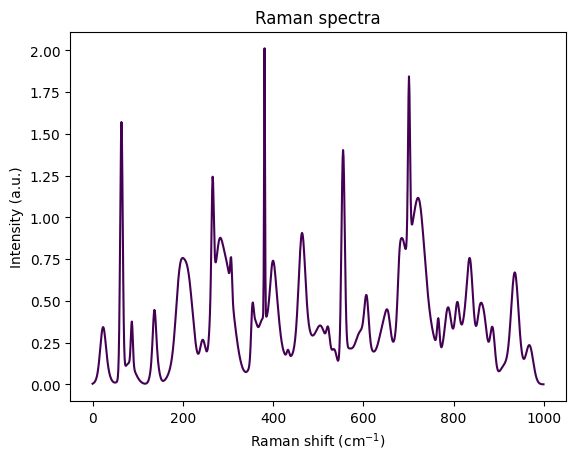

In [48]:
# Generate synthetic spectrum
spectra = rp.synth.generate_spectra(num_spectra=1, n_bands=1000, realistic=True, seed=10)

# And show it
rp.plot.spectra(spectra[0])
rp.plot.show()

Visually, the spectrum looks like an overlay of several peaks. Each peak roughly has the form of a bell curve, resp., a [Gaussian function](https://en.wikipedia.org/wiki/Gaussian_function).
The Gaussian shape sounds reasonable, since we expect the sample to scatter at certain wavenumbers - and as usual for measurements, this scatter will be noisy and thus peaks rather bell shaped than [Dirac functions](https://en.wikipedia.org/wiki/Dirac_delta_function).

Following this intuition, we start with a simplified notion of a spectrum as a sum of Gaussian functions, each of which corresponds to an idealized peak of amplitude $a$.
Letting $x$ be the Raman shift, a Gaussian peak is a spectrum of the form

$$
f(x) = a \cdot e^{-\frac{(x-\mu)^2}{2 w^2}}
$$

and we refer to $a$ as the amplitude, $\mu$ the mean, and $w$ the width.
Let's code a function that creates a peak. For simplicity we will assume here that our spectra all are between 0 and 1000 $\text{cm}^{-1}$ and comprise of 1000 bins, i.e., the numerical resolution is $1 \text{cm}^{-1}$.

In [49]:
def peak(pos: float, width: float) -> np.ndarray:
    # For simplicity we set spectral range and sample number
    # to constants.
    x = np.linspace(0,1000, 1000)

    # Gauss function, with amplitude 1.
    return 1 * np.exp( -(x - pos)**2 / (2*width**2) )

We can now create a simplified first spectrum comprising peaks at 500 and 750 of amplitude 1 and widths 10 and amplitude 1/5 and width 30.

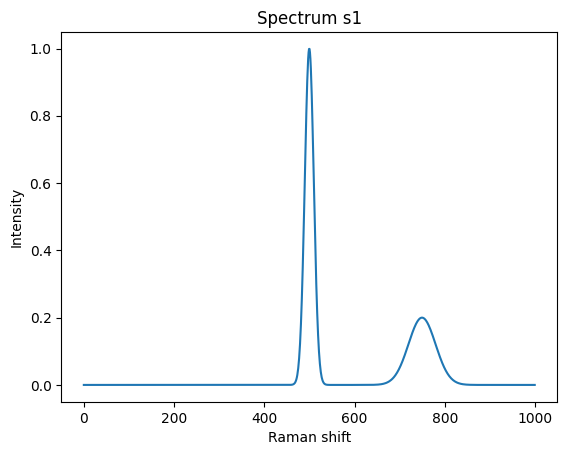

In [50]:
# Simple spectrum
s1 = peak(500,10) + 1/5*peak(750,30)

plt.figure()
plt.plot(s1)
plt.title("Spectrum s1")
plt.xlabel("Raman shift")
plt.ylabel("Intensity");

Let's create a second spectrum.

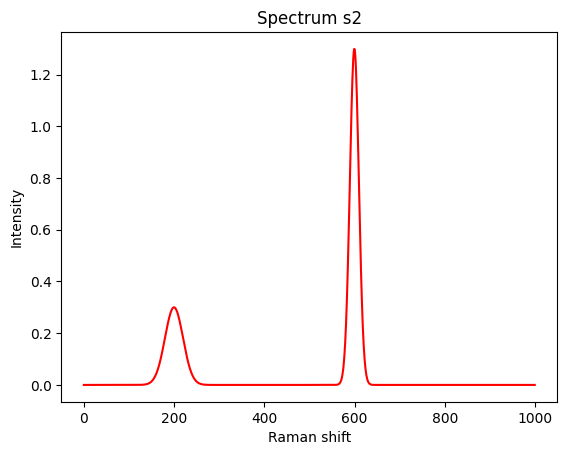

In [51]:
# Another simple spectrum
s2 = 0.3*peak(200,20) + 1.3*peak(600,10)

plt.figure()
plt.plot(s2, 'r')
plt.title("Spectrum s2")
plt.xlabel("Raman shift")
plt.ylabel("Intensity");

It is time to overlay both into a single spectrum. We assume the (bio-)chemical species responsible for spectrum $s_1$ is available in concentration $c_1 = 0.2$ and the species for $s_2$ in $c_2 = 0.5$.

While a priori this is a strong assumption, we assume that spectra are composed linearly, proportional to the concentrations of their components.

We can thus code a mixing function for spectra of components as:

In [52]:
def mix(spec: list[np.ndarray], coefficients: list[float]) -> np.ndarray:
    """Mix spectra with given coefficients."""

    if len(spec) == 0:
        raise ValueError("Expecting at least 1 spectrum")
    if len(spec) != len(coefficients):
        raise ValueError("Number of spectra and coefficients must match")

    ret = np.zeros_like(spec[0])
    for i, s in enumerate(spec):
        ret += coefficients[i] * s
    return ret

Resulting in the following spectrum (in black). The two original spectra are shown in blue and red.

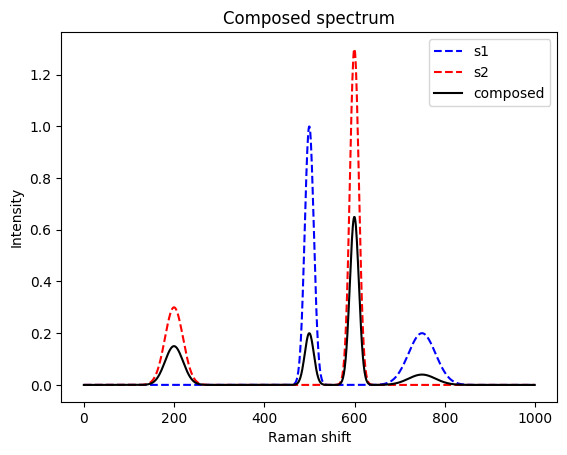

In [53]:
mixed = mix([s1, s2], [0.2, 0.5])

plt.figure()
plt.plot(s1, 'b--', label='s1')
plt.plot(s2, 'r--', label='s2')
plt.plot(mixed, 'k', label='composed')
plt.title("Composed spectrum")
plt.xlabel("Raman shift")
plt.ylabel("Intensity")
plt.legend();

When analyzing a sample, the game is reversed. It is nature that mixes and we need to find back the original coefficients.

Concretely, the problem we would like to solve is finding the two coefficients $c_1$ and $c_2$ back from the mixed spectrum, assuming that we know it is a mix of $s_1$ and $s_2$.
Using matrix notation, we can phrase the problem as solving the least square problem

$$
\min_c \|Sc - m\|_2
$$

where

$$
S = \begin{bmatrix}
{\vec s_{1}} & \vec s_{2} \\
\end{bmatrix}
$$


$$
c = \begin{bmatrix}
c_{1}\\
c_{n}
\end{bmatrix}
$$

and $m$ is the mixed spectrum. 

In [54]:
def demix(components: list[np.ndarray], mixed: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    S = np.vstack(components).T
    c, residuals, _, _ = np.linalg.lstsq(a=S, b=mixed, rcond=None)
    return c, residuals

c, residuals = demix(components=[s1, s2], mixed=mixed)
print(f"The coefficients are {c}.\nThe sums of squared residuals are {residuals}.")

The coefficients are [0.2 0.5].
The sums of squared residuals are [9.20547852e-31].


So, indeed, we successfully found back the two concentrations.

## More involved spectra

The above example was well behaved with respect to several properties:
1. All peaks are well separated and do not overlap. Neither between spectra, nor within a spectrum.
2. We knew exactly which species are present.
3. A perfectly clean spectrum was assumed: no background signal and no measurement were present.

We start by elevating (1) and (2). The next mixed spectrum has more involved spectra with overlapping peaks between and within a spectrum. Further, we are not sure if two other candidate species are present. 

The coefficients are [ 2.00000000e-01  5.00000000e-01  9.15446698e-18 -9.07151373e-17].
The sums of squared residuals is [2.32410096e-30].


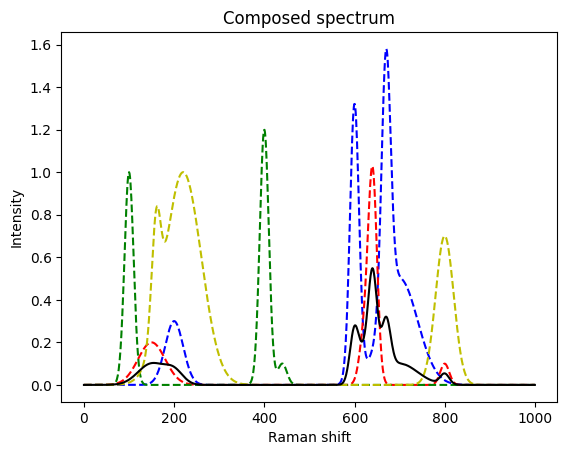

In [55]:
s3 = 0.3*peak(200,20) + 1.3*peak(600,10) + 1.2*peak(670,10) + 0.5*peak(700,40)
s4 = 0.2*peak(150,30) + 0.2*peak(620,10) + 1.0*peak(640,10) + 0.1*peak(800,10)
s5 = 1.0*peak(100,10) + 1.2*peak(400,10) + 0.1*peak(440,10)
s6 = 0.5*peak(160,10) + 1.0*peak(220,40) + 0.7*peak(800,20)
mixed = mix([s3, s4, s5, s6], [0.2, 0.5, 0.0, 0.0])

plt.figure()
plt.plot(s3, 'b--')
plt.plot(s4, 'r--')
plt.plot(s5, 'g--')
plt.plot(s6, 'y--')
plt.plot(mixed, 'k')
plt.title("Composed spectrum")
plt.xlabel("Raman shift")
plt.ylabel("Intensity")

c, residuals = demix(components=[s3, s4, s5, s6], mixed=mixed)
print(f"The coefficients are {c}.\nThe sums of squared residuals is {residuals}.")

Again, we found back the initial concentrations.

Let's make it even more difficult and add noise. Measurement noise is often composed of an additive and a multiplicative component. Here, we assume a multiplicative component, first. We will latter also include an additive component - the background signal.

In [56]:
def make_noisy(spec: list[np.ndarray], factor=0.1) -> list[np.ndarray]:
    ret = []
    for s in spec:
        gaussian_multiplicative_noise = np.random.normal(loc=1.0, scale=factor, size=s.shape)
        ret.append(s * gaussian_multiplicative_noise)
    return ret

The coefficients are [ 2.03043721e-01  4.78771439e-01  5.85396227e-05 -1.27394654e-04].
The sums of squared residuals is [0.20819475].


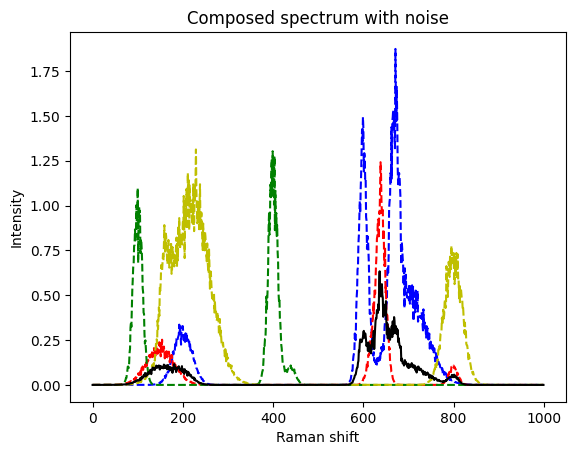

In [57]:
s3 = 0.3*peak(200,20) + 1.3*peak(600,10) + 1.2*peak(670,10) + 0.5*peak(700,40)
s4 = 0.2*peak(150,30) + 0.2*peak(620,10) + 1.0*peak(640,10) + 0.1*peak(800,10)
s5 = 1.0*peak(100,10) + 1.2*peak(400,10) + 0.1*peak(440,10)
s6 = 0.5*peak(160,10) + 1.0*peak(220,40) + 0.7*peak(800,20)

# make noisy
s3_noisy, s4_noisy, s5_noisy, s6_noisy = make_noisy([s3, s4, s5, s6])

# use the real / not noisy compounds to create the spectrum
mixed = mix([s3, s4, s5, s6], [0.2, 0.5, 0.0, 0.0])
# and make it noisy
mixed_noisy = make_noisy([mixed])[0]

plt.figure()
plt.plot(s3_noisy, 'b--')
plt.plot(s4_noisy, 'r--')
plt.plot(s5_noisy, 'g--')
plt.plot(s6_noisy, 'y--')
plt.plot(mixed_noisy, 'k')
plt.title("Composed spectrum with noise")
plt.xlabel("Raman shift")
plt.ylabel("Intensity")

c, residuals = demix(components=[s3_noisy, s4_noisy, s5_noisy, s6_noisy], mixed=mixed_noisy)
print(f"The coefficients are {c}.\nThe sums of squared residuals is {residuals}.")

This is still a very good match to the real coefficients. The method seems to be quite robust.

After this warmup rounds, we are ready to proceed to real spectra. We do not only expect many more peaks in such spectra, in particular if they come from complex samples like bacteria, but will also have to treat the previously mentioned background signal.

## Bacterial spectra

Following the tutorial on [RamanSPy](https://ramanspy.readthedocs.io/en/latest/datasets.html#bacteria-data) we next download a dataset of bacterial spectra obtained by [Ho et al. (Nat Commun, 2019)](https://www.nature.com/articles/s41467-019-12898-9).
Like in the [RamanSPy - loading bacterial data](https://ramanspy.readthedocs.io/en/latest/auto_tutorials/iii-datasets/plot_i_bacteria.html#sphx-glr-auto-tutorials-iii-datasets-plot-i-bacteria-py) tutorial, we load and show the data afterwards.

[INFO] <module>: Dataset already exists at tmp_data/bacteria_dataset.zip, skipping download.


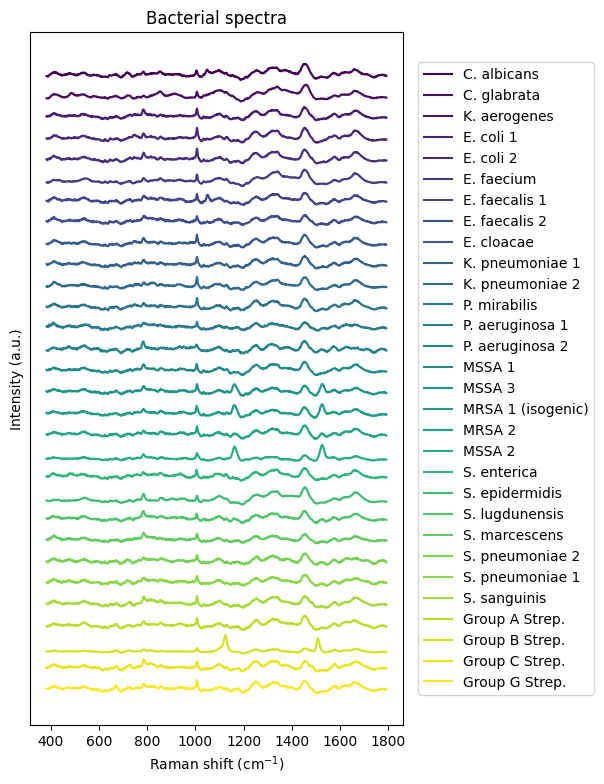

In [58]:
import requests
from pathlib import Path
import zipfile

# Change this to the downloaded data dir
data_dir = Path("tmp_data")
data_dir.mkdir(exist_ok=True)

# Download bacterial spectra following the RamanSPy tutorial
dropbox_url = "https://www.dropbox.com/scl/fo/fb29ihfnvishuxlnpgvhg/AJToUtts-vjYdwZGeqK4k-Y?rlkey=r4p070nsuei6qj3pjp13nwf6l&e=1&dl=1"
output_path = data_dir / "bacteria_dataset.zip"

if not output_path.exists():
    response = requests.get(dropbox_url)
    with open(output_path, "wb") as f:
        f.write(response.content)
    logger.info(f"Downloaded dataset to {output_path}")
else:
    logger.info(f"Dataset already exists at {output_path}, skipping download.")

# Unzip the file
with zipfile.ZipFile(output_path, "r") as zip_ref:
    zip_ref.extractall(data_dir)

# Get the training data
X_train, y_train = rp.datasets.bacteria("val", folder=data_dir)
y_labels, _ = rp.datasets.bacteria("labels")

# Normalize spectra
spectra = [[X_train[y_train == species_id]] for species_id in list(np.unique(y_train))]
spectra_norm = rp.preprocessing.normalise.MinMax().apply(spectra)

# Plot all spectra
plt.figure(figsize=(6.5, 9))
rp.plot.mean_spectra(
    spectra_norm,
    label=y_labels,
    plot_type="single stacked",
    title="Bacterial spectra"
);


There is one with _E. coli_ that particularly interests us.

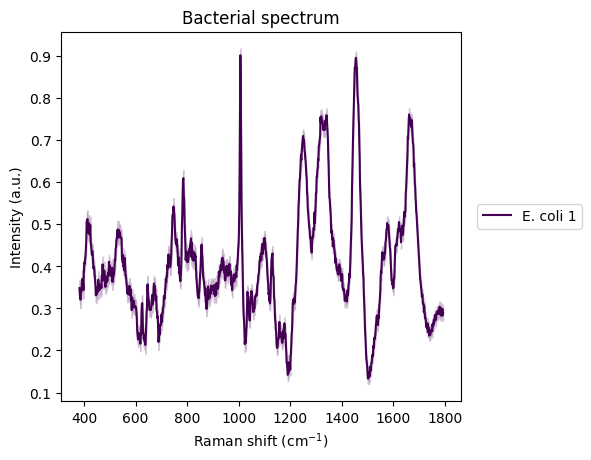

In [59]:
plt.figure()
idx_ecoli = 3
rp.plot.mean_spectra(
    spectra_norm[idx_ecoli],
    label=y_labels[idx_ecoli],
    plot_type="single stacked",
    title="Bacterial spectrum"
);

Text(0.5, 1.0, 'Mixed bacterial spectrum')

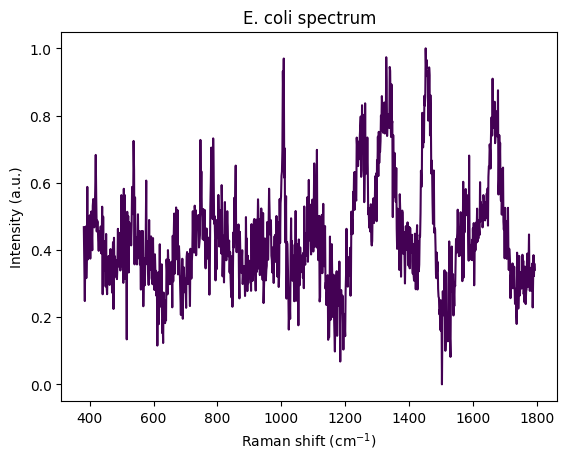

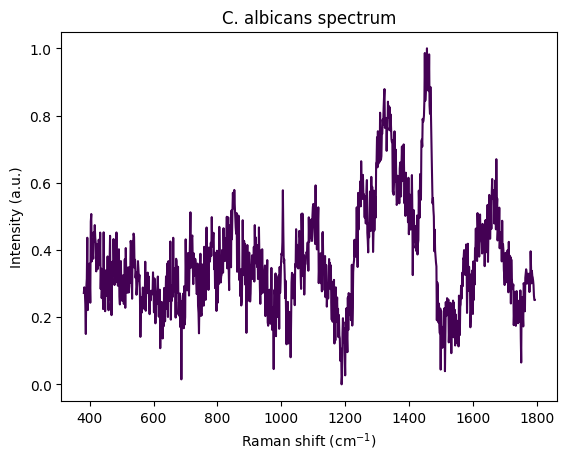

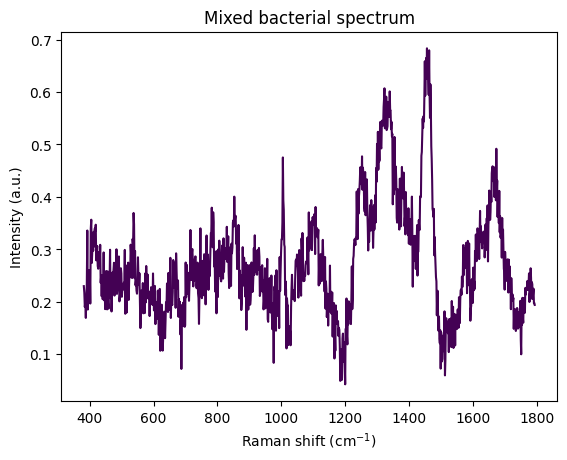

In [60]:
# the two components
plt.figure()
ecoli_spectrum = spectra[idx_ecoli][0][0]
rp.plot.spectra(ecoli_spectrum)
plt.title("E. coli spectrum")

plt.figure()
calbicans_spectrum = spectra[0][0][0]
rp.plot.spectra(calbicans_spectrum)
plt.title("C. albicans spectrum")

# creating a mixed one
to_mix = [ecoli_spectrum, calbicans_spectrum]
cs = np.array([0.2, 0.5])
mixed_bac = rp.synth.mix(to_mix, cs, mixture_mode='linear', noise=False, baseline=False, seed=42)

plt.figure()
rp.plot.spectra(mixed_bac)
plt.title("Mixed bacterial spectrum")

In [61]:
c, redidual = demix(components=[ecoli_spectrum.spectral_data, calbicans_spectrum.spectral_data], mixed=mixed_bac.spectral_data)
print(f"The coefficients are {c} and the sums of squared residuals is {residuals}.")

The coefficients are [0.2 0.5] and the sums of squared residuals is [0.20819475].


## Removing noise and a background signal

- May exist, e.g., because of a fluorescent background.
- Assume the spectrum of the background is not known and can not be simply subtracted.
- Estimate the baseline and subtract it. Also called baseline correction.

Let's create a synthetic spectrum with a simple background and noise.

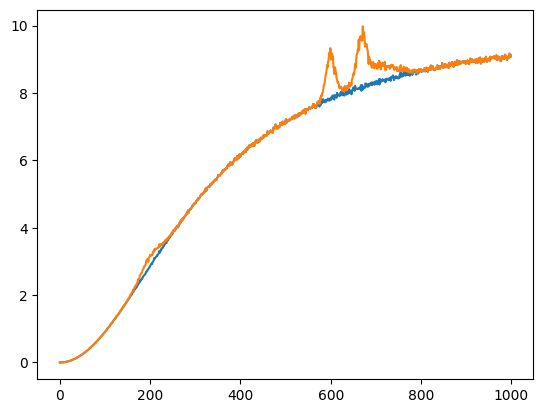

In [62]:
x = np.linspace(0,100, 1000)

# make a noisy background
background_signal = make_noisy(
    [x**2 / (1 + x**2/1000) * 1/100],
    factor=0.005
)
plt.plot(background_signal[0])

# and add it to our signal
s3_noisy_bck = background_signal[0] + s3_noisy
plt.plot(s3_noisy_bck);

Same for the other signals.

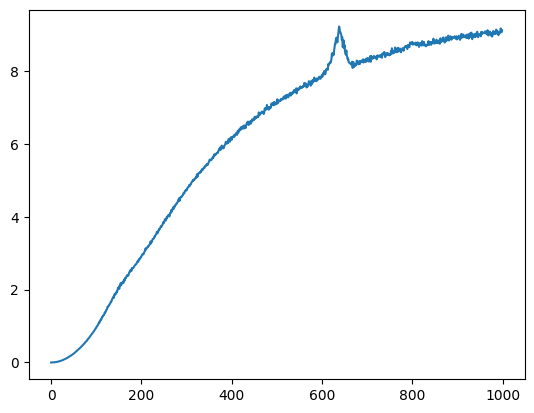

In [63]:
s4_noisy_bck = background_signal[0] + s4_noisy
plt.plot(s4_noisy_bck);

### Removing noise: Savitzky–Golay filter

Given a signal, one can locally, i.e., within a symmetric window of a fixed size around the point to be approximated, fit a least-square error polynomial. The simplest such filter is a non-causal moving average. The filter is a least-squares solution to fitting a polynomial of degree 0.

Further literature
- Reading and discussing [Savitzky–Golay filters](https://en.wikipedia.org/wiki/Savitzky–Golay_filter) as a way to locally fit a polynomial to the signal, or equivalently, perform a convolution with a non-causal filter signal.
- The paper [Savitzky and Golay (1964)](https://pubs.acs.org/doi/abs/10.1021/ac60214a047).

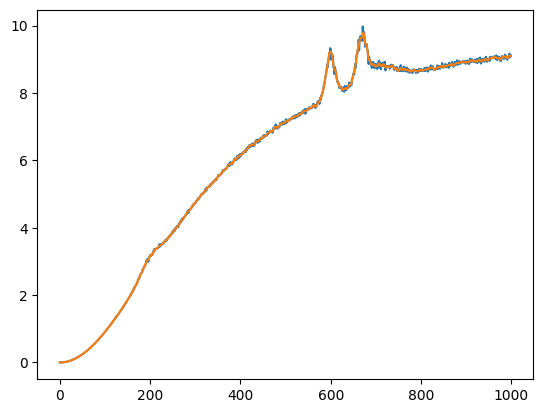

In [64]:
s3_denoise_est = scipy.signal.savgol_filter(x=s3_noisy_bck, window_length=9, polyorder=3)

plt.figure()
plt.plot(s3_noisy_bck)
plt.plot(s3_denoise_est);

### Removing the background

Text(0.5, 1.0, 'Estimated signal and signal')

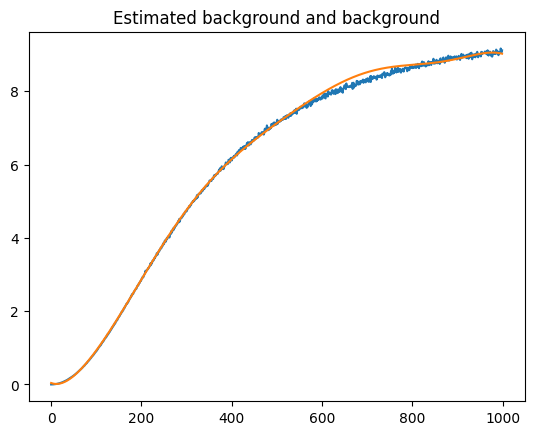

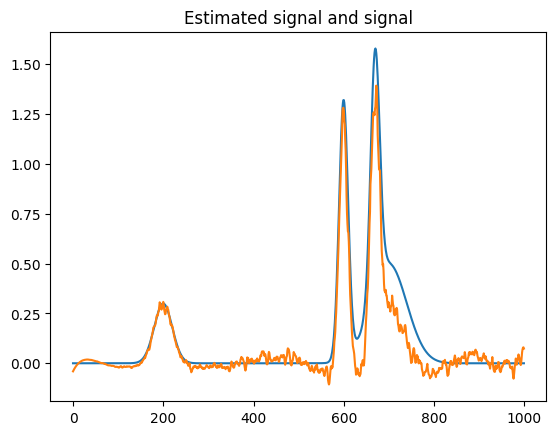

In [65]:
# setup the preprocessing pipeline
pipe = rp.preprocessing.protocols.Pipeline([
    # rp.preprocessing.denoise.SavGol(window_length=9, polyorder=3),
    rp.preprocessing.baseline.IModPoly(poly_order=10),
])

# apply pipeline
s3_est = pipe.apply(rp.Spectrum(s3_denoise_est, x))

# background estimate
bkg_est = s3_denoise_est - s3_est.spectral_data

# plot the results
# _ = rp.plot.spectra(s3_est, plot_type='separate')

plt.figure()
plt.plot(background_signal[0])
plt.plot(bkg_est)
plt.title("Estimated background and background")

plt.figure()
plt.plot(s3)
plt.plot(s3_est.spectral_data)
plt.title("Estimated signal and signal")

More information on background removal in signals can be found at the page of the Python package [pybaselines](https://pybaselines.readthedocs.io/en/latest/index.html). For example, you can checkout this [example](https://pybaselines.readthedocs.io/en/latest/examples/general/plot_noisy_data.html#sphx-glr-examples-general-plot-noisy-data-py) as a start.

### Further literature

- Measuring DNA concentration and quality via spectrophotometry: [Waldron (addgene blog, 2025)](https://blog.addgene.org/whats-in-your-tube-a-quick-guide-to-measuring-dna-by-spectrophotometry)

<hr>
**License**: © 2025 Matthias Függer and Thomas Nowak. Licensed under [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/).